In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
df = pd.read_csv("../data/raw/ieee-fraud-detection/train_transaction.csv")


In [7]:
df.shape

(590540, 394)

In [8]:
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
df.columns.tolist()

['TransactionID',
 'isFraud',
 'TransactionDT',
 'TransactionAmt',
 'ProductCD',
 'card1',
 'card2',
 'card3',
 'card4',
 'card5',
 'card6',
 'addr1',
 'addr2',
 'dist1',
 'dist2',
 'P_emaildomain',
 'R_emaildomain',
 'C1',
 'C2',
 'C3',
 'C4',
 'C5',
 'C6',
 'C7',
 'C8',
 'C9',
 'C10',
 'C11',
 'C12',
 'C13',
 'C14',
 'D1',
 'D2',
 'D3',
 'D4',
 'D5',
 'D6',
 'D7',
 'D8',
 'D9',
 'D10',
 'D11',
 'D12',
 'D13',
 'D14',
 'D15',
 'M1',
 'M2',
 'M3',
 'M4',
 'M5',
 'M6',
 'M7',
 'M8',
 'M9',
 'V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'V29',
 'V30',
 'V31',
 'V32',
 'V33',
 'V34',
 'V35',
 'V36',
 'V37',
 'V38',
 'V39',
 'V40',
 'V41',
 'V42',
 'V43',
 'V44',
 'V45',
 'V46',
 'V47',
 'V48',
 'V49',
 'V50',
 'V51',
 'V52',
 'V53',
 'V54',
 'V55',
 'V56',
 'V57',
 'V58',
 'V59',
 'V60',
 'V61',
 'V62',
 'V63',
 'V64',
 'V

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), str(14)
memory usage: 1.7 GB


In [11]:
df["isFraud"].value_counts()

isFraud
0    569877
1     20663
Name: count, dtype: int64

In [12]:
df["isFraud"].value_counts(normalize=True)*100

isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64

In [13]:
df.groupby("isFraud")["TransactionAmt"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,134.511665,239.395078,0.251,43.970,68.5,120.0,31937.391
1,20663.0,149.244779,232.212163,0.292,35.044,75.0,161.0,5191.000


In [14]:
df.groupby("isFraud")["TransactionAmt"].mean()

isFraud
0    134.511665
1    149.244779
Name: TransactionAmt, dtype: float64

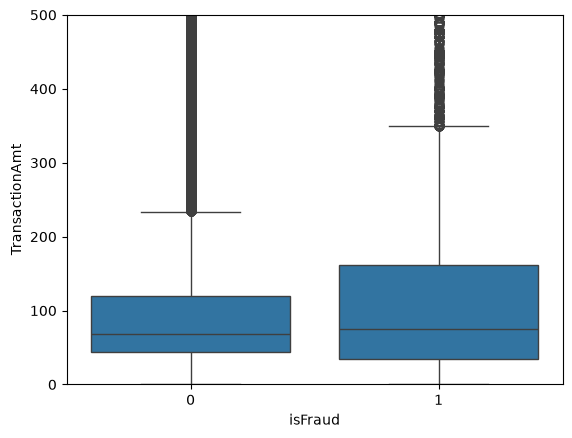

In [15]:
sns.boxplot(
    data=df,
    x="isFraud",
    y="TransactionAmt"
)
plt.ylim(0,500)
plt.show()

In [16]:
identity_df=pd.read_csv("../data/raw/ieee-fraud-detection/train_identity.csv")

In [17]:
identity_df.shape

(144233, 41)

In [18]:
identity_df.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [19]:
identity_df.columns.tolist()

['TransactionID',
 'id_01',
 'id_02',
 'id_03',
 'id_04',
 'id_05',
 'id_06',
 'id_07',
 'id_08',
 'id_09',
 'id_10',
 'id_11',
 'id_12',
 'id_13',
 'id_14',
 'id_15',
 'id_16',
 'id_17',
 'id_18',
 'id_19',
 'id_20',
 'id_21',
 'id_22',
 'id_23',
 'id_24',
 'id_25',
 'id_26',
 'id_27',
 'id_28',
 'id_29',
 'id_30',
 'id_31',
 'id_32',
 'id_33',
 'id_34',
 'id_35',
 'id_36',
 'id_37',
 'id_38',
 'DeviceType',
 'DeviceInfo']

In [20]:
df["TransactionID"].head()

0    2987000
1    2987001
2    2987002
3    2987003
4    2987004
Name: TransactionID, dtype: int64

In [21]:
identity_df["TransactionID"].head()

0    2987004
1    2987008
2    2987010
3    2987011
4    2987016
Name: TransactionID, dtype: int64

In [22]:
df.columns.tolist()

['TransactionID',
 'isFraud',
 'TransactionDT',
 'TransactionAmt',
 'ProductCD',
 'card1',
 'card2',
 'card3',
 'card4',
 'card5',
 'card6',
 'addr1',
 'addr2',
 'dist1',
 'dist2',
 'P_emaildomain',
 'R_emaildomain',
 'C1',
 'C2',
 'C3',
 'C4',
 'C5',
 'C6',
 'C7',
 'C8',
 'C9',
 'C10',
 'C11',
 'C12',
 'C13',
 'C14',
 'D1',
 'D2',
 'D3',
 'D4',
 'D5',
 'D6',
 'D7',
 'D8',
 'D9',
 'D10',
 'D11',
 'D12',
 'D13',
 'D14',
 'D15',
 'M1',
 'M2',
 'M3',
 'M4',
 'M5',
 'M6',
 'M7',
 'M8',
 'M9',
 'V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'V29',
 'V30',
 'V31',
 'V32',
 'V33',
 'V34',
 'V35',
 'V36',
 'V37',
 'V38',
 'V39',
 'V40',
 'V41',
 'V42',
 'V43',
 'V44',
 'V45',
 'V46',
 'V47',
 'V48',
 'V49',
 'V50',
 'V51',
 'V52',
 'V53',
 'V54',
 'V55',
 'V56',
 'V57',
 'V58',
 'V59',
 'V60',
 'V61',
 'V62',
 'V63',
 'V64',
 'V

In [23]:
print(df.shape)
print(identity_df.shape)

(590540, 394)
(144233, 41)


In [24]:
data = df.merge(
    identity_df,
    on="TransactionID",
    how="left"
)

In [25]:
df.shape

(590540, 394)

In [26]:
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), str(14)
memory usage: 1.7 GB


In [28]:
data["isFraud"].value_counts()

isFraud
0    569877
1     20663
Name: count, dtype: int64

In [29]:
data["hour"] =(
    (data["TransactionDT"]//3600)%24
)

C:\Users\srikanth\AppData\Local\Temp\ipykernel_18336\1936872000.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["hour"] =(


In [30]:
data["hour"] =(
    data["TransactionDT"]//(3600*24)
)

In [31]:
data["log_amount"] =np.log1p(data["TransactionAmt"])

C:\Users\srikanth\AppData\Local\Temp\ipykernel_18336\4109404565.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["log_amount"] =np.log1p(data["TransactionAmt"])


In [32]:
data["missing_count"] = data.isnull().sum(axis=1)

C:\Users\srikanth\AppData\Local\Temp\ipykernel_18336\4230001411.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["missing_count"] = data.isnull().sum(axis=1)


In [33]:
data["email_match"] = (
    data["P_emaildomain"] == data["R_emaildomain"]
).astype(int)

C:\Users\srikanth\AppData\Local\Temp\ipykernel_18336\4134528945.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["email_match"] = (


In [34]:
data["dist1_missing"] = data["dist1"].isnull().astype(int)
data["dist2_missing"] = data["dist2"].isnull().astype(int)

C:\Users\srikanth\AppData\Local\Temp\ipykernel_18336\140721719.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["dist1_missing"] = data["dist1"].isnull().astype(int)
C:\Users\srikanth\AppData\Local\Temp\ipykernel_18336\140721719.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["dist2_missing"] = data["dist2"].isnull().astype(int)


In [35]:
identity_df["DeviceType"].value_counts(dropna=False)

DeviceType
desktop    85165
mobile     55645
NaN         3423
Name: count, dtype: int64

In [36]:
identity_df["DeviceInfo"].value_counts(dropna=False).head(20)


DeviceInfo
Windows                        47722
NaN                            25567
iOS Device                     19782
MacOS                          12573
Trident/7.0                     7440
rv:11.0                         1901
rv:57.0                          962
SM-J700M Build/MMB29K            549
SM-G610M Build/MMB29K            461
SM-G531H Build/LMY48B            410
rv:59.0                          362
SM-G935F Build/NRD90M            334
SM-G955U Build/NRD90M            328
SM-G532M Build/MMB29T            316
ALE-L23 Build/HuaweiALE-L23      312
SM-G950U Build/NRD90M            290
SM-G930V Build/NRD90M            274
rv:58.0                          269
rv:52.0                          256
SAMSUNG                          235
Name: count, dtype: int64

In [37]:
import xgboost
import sklearn

print("XGBoost:", xgboost.__version__)
print("Scikit-learn:", sklearn.__version__)

XGBoost: 3.4.1
Scikit-learn: 1.9.0


In [38]:
data = data.sort_values("TransactionDT").reset_index(drop=True)

n = len(data)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_data = data.iloc[:train_end].copy()
val_data = data.iloc[train_end:val_end].copy()
test_data = data.iloc[val_end:].copy()

X_train = train_data.drop(columns=["isFraud"])
y_train = train_data["isFraud"]

X_val = val_data.drop(columns=["isFraud"])
y_val = val_data["isFraud"]

X_test = test_data.drop(columns=["isFraud"])
y_test = test_data["isFraud"]

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (413378, 439) (413378,)
Validation: (88581, 439) (88581,)
Test: (88581, 439) (88581,)


In [39]:
print("Numerical columns:",
      X_train.select_dtypes(exclude="object").shape[1])

print("Categorical columns:",
      X_train.select_dtypes(include="object").shape[1])

Numerical columns: 408
Categorical columns: 31


C:\Users\srikanth\AppData\Local\Temp\ipykernel_18336\3021159951.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X_train.select_dtypes(include="object").shape[1])


In [40]:
categorical_cols = X_train.select_dtypes(
    include="object"
).columns.tolist()

print(categorical_cols)

['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']


C:\Users\srikanth\AppData\Local\Temp\ipykernel_18336\4284450254.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(


In [41]:
freq_cols = [
    "ProductCD",
    "card4",
    "card6",
    "P_emaildomain",
    "R_emaildomain",
    "DeviceType",
    "DeviceInfo"
]

In [42]:
for col in freq_cols:

    freq = train_data[col].value_counts(dropna=False)

    train_data[col + "_freq"] = (
        train_data[col].map(freq)
    )

    val_data[col + "_freq"] = (
        val_data[col].map(freq).fillna(0)
    )

    test_data[col + "_freq"] = (
        test_data[col].map(freq).fillna(0)
    )

In [43]:
baseline_features = [
    "TransactionAmt",
    "TransactionDT",

    "hour",
    "day",

    "card1",
    "card2",
    "card3",
    "card5",

    "addr1",
    "addr2",

    "dist1",
    "dist2",

    "C1",
    "C2",
    "C3",
    "C4",
    "C5",
    "C6",

    "V1",
    "V2",
    "V3",
    "V4",
    "V5",
    "V6",

    "ProductCD_freq",
    "card4_freq",
    "card6_freq",
    "P_emaildomain_freq",
    "R_emaildomain_freq",
    "DeviceType_freq",
    "DeviceInfo_freq"
]

In [44]:
print(train_data.columns.tolist())
print(baseline_features)

['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V

In [45]:
missing_features = [
    col for col in baseline_features
    if col not in train_data.columns
]

print("Missing features:", missing_features)

Missing features: ['day']


In [46]:
print("train:", train_data.shape)
print("validation:", val_data.shape)

print("day in train:", "day" in train_data.columns)
print("day in val:", "day" in val_data.columns)

train: (413378, 447)
validation: (88581, 447)
day in train: False
day in val: False


In [47]:
train_data["day"] = train_data["TransactionDT"] // (24 * 60 * 60)
val_data["day"] = val_data["TransactionDT"] // (24 * 60 * 60)

In [48]:
print(train_data["day"].head())
print(val_data["day"].head())

0    1
1    1
2    1
3    1
4    1
Name: day, dtype: int64
413378    120
413379    120
413380    120
413381    120
413382    120
Name: day, dtype: int64


In [49]:
X_train = train_data[baseline_features]
y_train = train_data["isFraud"]

X_val = val_data[baseline_features]
y_val = val_data["isFraud"]

In [50]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print(scale_pos_weight)

27.434310083918007


In [51]:
from xgboost import XGBClassifier

In [52]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

In [53]:
model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

[0]	validation_0-aucpr:0.24910
[50]	validation_0-aucpr:0.36414
[100]	validation_0-aucpr:0.39729
[150]	validation_0-aucpr:0.41272
[200]	validation_0-aucpr:0.42804
[250]	validation_0-aucpr:0.43523
[299]	validation_0-aucpr:0.44393


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [54]:
val_prob =model.predict_proba(X_val)[:,1]

In [55]:
from sklearn.metrics import(
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

In [56]:
val_pred =(val_prob >= 0.5).astype(int)

In [57]:
print("Precision:",
      precision_score(y_val, val_pred))

print("Recall:",
      recall_score(y_val, val_pred))

print("F1:",
      f1_score(y_val, val_pred))

print("PR-AUC:",
      average_precision_score(y_val, val_prob))

Precision: 0.35938220378054403
Recall: 0.5124917817225509
F1: 0.42249322493224933
PR-AUC: 0.44404844347909006


In [58]:
print(confusion_matrix(y_val, val_pred))

[[82760  2779]
 [ 1483  1559]]


In [59]:
thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

for threshold in thresholds:

    pred = (val_prob >= threshold).astype(int)

    precision = precision_score(y_val, pred)
    recall = recall_score(y_val, pred)
    f1 = f1_score(y_val, pred)

    print(
        f"Threshold={threshold:.2f} "
        f"Precision={precision:.3f} "
        f"Recall={recall:.3f} "
        f"F1={f1:.3f}"
    )

Threshold=0.10 Precision=0.066 Recall=0.901 F1=0.124
Threshold=0.20 Precision=0.115 Recall=0.783 F1=0.201
Threshold=0.30 Precision=0.185 Recall=0.681 F1=0.291
Threshold=0.40 Precision=0.270 Recall=0.587 F1=0.370
Threshold=0.50 Precision=0.359 Recall=0.512 F1=0.422
Threshold=0.60 Precision=0.458 Recall=0.442 F1=0.450
Threshold=0.70 Precision=0.575 Recall=0.385 F1=0.461
Threshold=0.80 Precision=0.686 Recall=0.315 F1=0.431
Threshold=0.90 Precision=0.784 Recall=0.252 F1=0.382


In [60]:
data["TransactionAmt_log"] = np.log1p(
    data["TransactionAmt"]
)

C:\Users\srikanth\AppData\Local\Temp\ipykernel_18336\2267051434.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["TransactionAmt_log"] = np.log1p(


In [61]:
data["is_night"] = (
    (data["hour"] < 6) |
    (data["hour"] >= 23)
).astype(int)

C:\Users\srikanth\AppData\Local\Temp\ipykernel_18336\2773904997.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["is_night"] = (


In [62]:
data["missing_count"] = data.isna().sum(axis=1)

In [63]:
data = data.sort_values("TransactionDT").reset_index(drop=True)

n = len(data)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_data = data.iloc[:train_end].copy()
val_data = data.iloc[train_end:val_end].copy()
test_data = data.iloc[val_end:].copy()

print("Train:", train_data.shape)
print("Validation:", val_data.shape)
print("Test:", test_data.shape)

Train: (413378, 442)
Validation: (88581, 442)
Test: (88581, 442)


In [64]:
print("Train fraud rate:", train_data["isFraud"].mean())
print("Validation fraud rate:", val_data["isFraud"].mean())
print("Test fraud rate:", test_data["isFraud"].mean())

Train fraud rate: 0.03516878014795175
Validation fraud rate: 0.03434145019812375
Test fraud rate: 0.03480430340592226


In [65]:
print(train_data["isFraud"].value_counts())

isFraud
0    398840
1     14538
Name: count, dtype: int64


In [66]:
X_train = train_data.drop(
    columns=["isFraud", "TransactionID"]
)

y_train = train_data["isFraud"]

X_val = val_data.drop(
    columns=["isFraud", "TransactionID"]
)

y_val = val_data["isFraud"]

X_test = test_data.drop(
    columns=["isFraud", "TransactionID"]
)

y_test = test_data["isFraud"]

In [67]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (413378, 440)
y_train: (413378,)
X_val: (88581, 440)
y_val: (88581,)
X_test: (88581, 440)
y_test: (88581,)


In [68]:
X_train = train_data.drop(columns=["isFraud", "TransactionID"])
y_train = train_data["isFraud"]

X_val = val_data.drop(columns=["isFraud", "TransactionID"])
y_val = val_data["isFraud"]

X_test = test_data.drop(columns=["isFraud", "TransactionID"])
y_test = test_data["isFraud"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (413378, 440)
y_train: (413378,)
X_val: (88581, 440)
y_val: (88581,)
X_test: (88581, 440)
y_test: (88581,)


In [69]:
categorical_cols = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_cols = X_train.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Numerical:", len(numerical_cols))
print("Categorical:", len(categorical_cols))
print(categorical_cols)

Numerical: 409
Categorical: 31
['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']


C:\Users\srikanth\AppData\Local\Temp\ipykernel_18336\4180716504.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(


In [70]:
categorical_cols = X_train.select_dtypes(
    include=["object", "string"]
).columns.tolist()

In [71]:
numerical_cols = X_train.select_dtypes(
    exclude=["object", "string"]
).columns.tolist()

In [72]:
freq_cols = [
    "ProductCD",
    "card4",
    "card6",
    "P_emaildomain",
    "R_emaildomain",
    "M1",
    "M2",
    "M3",
    "M4",
    "M5",
    "M6",
    "M7",
    "M8",
    "M9",
    "DeviceType",
    "DeviceInfo"
]

In [73]:
frequency_maps = {}

for col in freq_cols:
    frequency_maps[col] = (
        X_train[col]
        .value_counts(dropna=False)
    )

In [74]:
for col in freq_cols:

    X_train[col + "_freq"] = (
        X_train[col]
        .map(frequency_maps[col])
    )

    X_val[col + "_freq"] = (
        X_val[col]
        .map(frequency_maps[col])
        .fillna(0)
    )

    X_test[col + "_freq"] = (
        X_test[col]
        .map(frequency_maps[col])
        .fillna(0)
    )

In [75]:
X_train = X_train.drop(columns=freq_cols)
X_val = X_val.drop(columns=freq_cols)
X_test = X_test.drop(columns=freq_cols)

In [76]:
print(
    "Remaining categorical:",
    len(
        X_train.select_dtypes(
            include=["object", "string"]
        ).columns
    )
)

Remaining categorical: 15


In [77]:
print(
    f"X_train memory: "
    f"{X_train.memory_usage(deep=True).sum() / 1024**3:.2f} GB"
)

X_train memory: 1.52 GB


In [78]:
print(
    "Missing values:",
    X_train.isna().sum().sum()
)


Missing values: 77317119


In [79]:
categorical_cols = X_train.select_dtypes(
    include=["object", "string"]
).columns.tolist()

numerical_cols = X_train.select_dtypes(
    exclude=["object", "string"]
).columns.tolist()

print("Numerical:", len(numerical_cols))
print("Categorical:", len(categorical_cols))

Numerical: 425
Categorical: 15


In [80]:
remaining_categorical = X_train.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print(remaining_categorical)

['id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38']


In [81]:
identity_freq_cols = [
    "id_12",
    "id_15",
    "id_16",
    "id_23",
    "id_27",
    "id_28",
    "id_29",
    "id_30",
    "id_31",
    "id_33",
    "id_34",
    "id_35",
    "id_36",
    "id_37",
    "id_38"
]

In [82]:
for col in identity_freq_cols:

    freq = X_train[col].value_counts(dropna=False)

    X_train[col + "_freq"] = X_train[col].map(freq)

    X_val[col + "_freq"] = (
        X_val[col]
        .map(freq)
        .fillna(0)
    )

    X_test[col + "_freq"] = (
        X_test[col]
        .map(freq)
        .fillna(0)
    )

In [83]:
X_train = X_train.drop(columns=identity_freq_cols)
X_val = X_val.drop(columns=identity_freq_cols)
X_test = X_test.drop(columns=identity_freq_cols)

In [84]:
remaining_categorical = X_train.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("Remaining categorical:", len(remaining_categorical))
print(remaining_categorical)

Remaining categorical: 0
[]


In [85]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (413378, 440)
X_val: (88581, 440)
X_test: (88581, 440)


In [86]:
print(X_train.dtypes.value_counts())

float64    401
int64       39
Name: count, dtype: int64


In [87]:
import numpy as np

print("Infinite values:", np.isinf(X_train).sum().sum())

Infinite values: 0


In [88]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("Negative:", negative)
print("Positive:", positive)
print("scale_pos_weight:", scale_pos_weight)

Negative: 398840
Positive: 14538
scale_pos_weight: 27.434310083918007


In [89]:
from xgboost import XGBClassifier

In [90]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,

    objective="binary:logistic",
    eval_metric="aucpr",

    scale_pos_weight=scale_pos_weight,

    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

In [91]:
model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

[0]	validation_0-aucpr:0.31658
[50]	validation_0-aucpr:0.46970
[100]	validation_0-aucpr:0.50149
[150]	validation_0-aucpr:0.51779
[200]	validation_0-aucpr:0.53025
[250]	validation_0-aucpr:0.54072
[299]	validation_0-aucpr:0.55096


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [92]:
val_prob = model.predict_proba(X_val)[:, 1]

In [93]:
print(val_prob[:10])

[0.10296898 0.980806   0.68620735 0.04860336 0.03345916 0.09426168
 0.60224044 0.316224   0.4300414  0.1944346 ]


In [94]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    confusion_matrix
)

In [95]:
val_pred = (val_prob >= 0.5).astype(int)

In [96]:
precision = precision_score(y_val, val_pred)
recall = recall_score(y_val, val_pred)
f1 = f1_score(y_val, val_pred)
pr_auc = average_precision_score(y_val, val_prob)

print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("PR-AUC:", pr_auc)

Precision: 0.3302752293577982
Recall: 0.650887573964497
F1: 0.43819851720703773
PR-AUC: 0.5510169374352344


In [97]:
print("Confusion Matrix:")
print(confusion_matrix(y_val, val_pred))

Confusion Matrix:
[[81524  4015]
 [ 1062  1980]]


In [98]:
thresholds = np.arange(0.10, 0.91, 0.05)

results = []

for threshold in thresholds:

    pred = (val_prob >= threshold).astype(int)

    precision = precision_score(
        y_val,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        pred,
        zero_division=0
    )

    results.append(
        [threshold, precision, recall, f1]
    )

In [99]:
threshold_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1"
    ]
)

threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.069071,0.946088,0.128744
1,0.15,0.095655,0.914859,0.173201
2,0.20,0.123265,0.872781,0.216021
3,0.25,0.153307,0.833662,0.258987
4,0.30,0.181846,0.790927,0.295705
5,0.35,0.213846,0.753452,0.333140
6,0.40,0.250114,0.720250,0.371293
7,0.45,0.288950,0.687705,0.406925
8,0.50,0.330275,0.650888,0.438199
9,0.55,0.374204,0.618014,0.466154


In [100]:
best_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

print("Best F1 threshold:", best_row["Threshold"])
print("Precision:", best_row["Precision"])
print("Recall:", best_row["Recall"])
print("F1:", best_row["F1"])
print("PR-AUC:", pr_auc)

Best F1 threshold: 0.7500000000000002
Precision: 0.6035729476818376
Recall: 0.46646942800788954
F1: 0.5262377155572038
PR-AUC: 0.5510169374352344


In [101]:
required_cols = [
    "TransactionID",
    "TransactionDT",
    "TransactionAmt"
]

for col in required_cols:
    print(col, col in train_data.columns)

TransactionID True
TransactionDT True
TransactionAmt True


In [102]:
train_data["hour"] = (
    (train_data["TransactionDT"] // 3600) % 24
)

val_data["hour"] = (
    (val_data["TransactionDT"] // 3600) % 24
)

test_data["hour"] = (
    (test_data["TransactionDT"] // 3600) % 24
)

In [103]:
train_data["day"] = (
    train_data["TransactionDT"] // (3600 * 24)
)

val_data["day"] = (
    val_data["TransactionDT"] // (3600 * 24)
)

test_data["day"] = (
    test_data["TransactionDT"] // (3600 * 24)
)

In [104]:
import numpy as np

for df in [train_data, val_data, test_data]:
    df["log_amount"] = np.log1p(df["TransactionAmt"])

In [105]:
amount_median = train_data["TransactionAmt"].median()
amount_std = train_data["TransactionAmt"].std()

print("Median amount:", amount_median)
print("Std amount:", amount_std)

Median amount: 68.95
Std amount: 238.007690001735


In [106]:
for df in [train_data, val_data, test_data]:
    df["amount_zscore"] = (
        (df["TransactionAmt"] - amount_median)
        / amount_std
    )

In [107]:
train_data[
    [
        "TransactionAmt",
        "hour",
        "day",
        "log_amount",
        "amount_zscore"
    ]
].head(10)

,TransactionAmt,hour,day,log_amount,amount_zscore
0,68.5,0,1,4.241327,-0.001891
1,29.0,0,1,3.401197,-0.167852
2,59.0,0,1,4.094345,-0.041805
3,50.0,0,1,3.931826,-0.079619
4,50.0,0,1,3.931826,-0.079619
5,49.0,0,1,3.912023,-0.083821
6,159.0,0,1,5.075174,0.378349
7,422.5,0,1,6.048554,1.485456
8,15.0,0,1,2.772589,-0.226673
9,117.0,0,1,4.770685,0.201884


In [108]:
train_data = train_data.sort_values(
    "TransactionDT"
).copy()

val_data = val_data.sort_values(
    "TransactionDT"
).copy()

test_data = test_data.sort_values(
    "TransactionDT"
).copy()

In [109]:
train_data["prev_card_time"] = (
    train_data.groupby("card1")["TransactionDT"]
    .shift(1)
)

In [110]:
train_data["card_time_since_prev"] = (
    train_data["TransactionDT"]
    - train_data["prev_card_time"]
)

In [111]:
train_data[
    [
        "TransactionID",
        "TransactionDT",
        "card1",
        "prev_card_time",
        "card_time_since_prev"
    ]
].head(20)

,TransactionID,TransactionDT,card1,prev_card_time,card_time_since_prev
0,2987000,86400,13926,NaN,NaN
1,2987001,86401,2755,NaN,NaN
2,2987002,86469,4663,NaN,NaN
3,2987003,86499,18132,NaN,NaN
4,2987004,86506,4497,NaN,NaN
5,2987005,86510,5937,NaN,NaN
6,2987006,86522,12308,NaN,NaN
7,2987007,86529,12695,NaN,NaN
8,2987008,86535,2803,NaN,NaN
9,2987009,86536,17399,NaN,NaN


In [112]:
val_data.groupby("card1").shift(1)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card2,card3,card4,card5,card6,...,hour,log_amount,missing_count,email_match,dist1_missing,dist2_missing,TransactionAmt_log,is_night,day,amount_zscore
413378,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
413379,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
413380,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
413381,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
413382,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501954,3488953.0,0.0,13151517.0,209.95,W,194.0,150.0,mastercard,166.0,debit,...,5.0,5.351621,231.0,0.0,0.0,1.0,5.351621,1.0,152.0,0.592418
501955,3488954.0,0.0,13151575.0,29.00,W,194.0,150.0,mastercard,166.0,debit,...,5.0,3.401197,210.0,0.0,1.0,1.0,3.401197,1.0,152.0,-0.167852
501956,3488955.0,0.0,13151580.0,312.95,W,194.0,150.0,mastercard,166.0,debit,...,5.0,5.749234,214.0,0.0,1.0,1.0,5.749234,1.0,152.0,1.025177
501957,3488956.0,0.0,13151717.0,774.00,W,194.0,150.0,mastercard,166.0,debit,...,5.0,6.652863,212.0,0.0,1.0,1.0,6.652863,1.0,152.0,2.962299


In [113]:
last_train_card_time = (
    train_data.groupby("card1")["TransactionDT"]
    .last()
)

In [114]:
val_data["prev_card_time"] = (
    val_data.groupby("card1")["TransactionDT"]
    .shift(1)
)

In [115]:
val_data["prev_card_time"] = (
    val_data["prev_card_time"]
    .fillna(
        val_data["card1"].map(last_train_card_time)
    )
)

In [116]:
val_data["card_time_since_prev"] = (
    val_data["TransactionDT"]
    - val_data["prev_card_time"]
)

In [117]:
last_val_card_time = (
    val_data.groupby("card1")["TransactionDT"]
    .last()
)

In [118]:
test_data["prev_card_time"] = (
    test_data.groupby("card1")["TransactionDT"]
    .shift(1)
)

In [119]:
test_data["prev_card_time"] = (
    test_data["prev_card_time"]
    .fillna(
        test_data["card1"].map(last_val_card_time)
    )
)

In [120]:
test_data["card_time_since_prev"] = (
    test_data["TransactionDT"]
    - test_data["prev_card_time"]
)

In [121]:
print(
    "Train non-null:",
    train_data["card_time_since_prev"].notna().sum()
)

print(
    "Validation non-null:",
    val_data["card_time_since_prev"].notna().sum()
)

print(
    "Test non-null:",
    test_data["card_time_since_prev"].notna().sum()
)

Train non-null: 401136
Validation non-null: 87906
Test non-null: 86621


In [122]:
print(
    val_data[
        [
            "TransactionID",
            "TransactionDT",
            "card1",
            "prev_card_time",
            "card_time_since_prev"
        ]
    ].head(20)
)

        TransactionID  TransactionDT  card1  prev_card_time  \
413378        3400378       10438003   7239      10369267.0   
413379        3400379       10438017  18227      10434799.0   
413380        3400380       10438043  11919      10437992.0   
413381        3400381       10438052   2377      10413970.0   
413382        3400382       10438065   7919      10437939.0   
413383        3400383       10438095   6394      10423668.0   
413384        3400384       10438110  11919      10438043.0   
413385        3400385       10438129  15885      10436654.0   
413386        3400386       10438129   8378      10152129.0   
413387        3400387       10438130   9500      10437922.0   
413388        3400388       10438135  15611       9220938.0   
413389        3400389       10438166   8378      10438129.0   
413390        3400390       10438167   5033      10431996.0   
413391        3400391       10438168   7468      10421267.0   
413392        3400392       10438185  14858      104351

In [123]:
train_data["card_txn_count_before"] = (
    train_data.groupby("card1").cumcount()
)

In [124]:
train_card_counts = (
    train_data["card1"]
    .value_counts()
)

In [125]:
val_data["card_txn_count_before"] = (
    val_data.groupby("card1").cumcount()
)

In [126]:
val_data["card_txn_count_before"] = (
    val_data["card_txn_count_before"]
    + val_data["card1"].map(train_card_counts).fillna(0)
)

In [127]:
all_pretest_card_counts = (
    pd.concat([
        train_data["card1"],
        val_data["card1"]
    ])
    .value_counts()
)

In [128]:
test_data["card_txn_count_before"] = (
    test_data.groupby("card1").cumcount()
)

In [129]:
test_data["card_txn_count_before"] = (
    test_data["card_txn_count_before"]
    + test_data["card1"].map(
        all_pretest_card_counts
    ).fillna(0)
)

In [130]:
print(
    train_data[
        ["card1", "TransactionDT", "card_txn_count_before"]
    ].head(20)
)

    card1  TransactionDT  card_txn_count_before
0   13926          86400                      0
1    2755          86401                      0
2    4663          86469                      0
3   18132          86499                      0
4    4497          86506                      0
5    5937          86510                      0
6   12308          86522                      0
7   12695          86529                      0
8    2803          86535                      0
9   17399          86536                      0
10  16496          86549                      0
11   4461          86555                      0
12   3786          86564                      0
13  12866          86585                      0
14  11839          86596                      0
15   7055          86618                      0
16   1790          86620                      0
17  11492          86668                      0
18   4663          86725                      1
19   7005          86730                

In [131]:
print(
    val_data[
        ["card1", "TransactionDT", "card_txn_count_before"]
    ].head(20)
)

        card1  TransactionDT  card_txn_count_before
413378   7239       10438003                   76.0
413379  18227       10438017                  599.0
413380  11919       10438043                  662.0
413381   2377       10438052                  489.0
413382   7919       10438065                10147.0
413383   6394       10438095                  201.0
413384  11919       10438110                  663.0
413385  15885       10438129                 7543.0
413386   8378       10438129                   93.0
413387   9500       10438130                 9680.0
413388  15611       10438135                    9.0
413389   8378       10438166                   94.0
413390   5033       10438167                 1778.0
413391   7468       10438168                  245.0
413392  14858       10438185                  919.0
413393   6530       10438186                 2099.0
413394  13481       10438191                  660.0
413395  16132       10438201                 2676.0
413396  1447

In [132]:
print(
    test_data[
        ["card1", "TransactionDT", "card_txn_count_before"]
    ].head(20)
)

        card1  TransactionDT  card_txn_count_before
501959   7919       13151880                12508.0
501960   1764       13151945                  592.0
501961   2455       13152098                 1527.0
501962   7919       13152112                12509.0
501963  10838       13152147                  207.0
501964   7919       13152158                12510.0
501965   4806       13152299                 1745.0
501966   7919       13152411                12511.0
501967   9633       13152443                 3647.0
501968   7919       13152444                12512.0
501969   4272       13152453                  960.0
501970   3178       13152636                  657.0
501971   7919       13152647                12513.0
501972   4806       13152804                 1746.0
501973   2803       13152859                 5220.0
501974  16136       13152921                 1662.0
501975   7919       13152979                12514.0
501976   7919       13153023                12515.0
501977   195

In [133]:
def add_card_velocity(current_df, history_df=None, window="1h"):

    current = current_df[
        ["TransactionID", "card1", "TransactionDT"]
    ].copy()

    if history_df is not None:
        history = history_df[
            ["TransactionID", "card1", "TransactionDT"]
        ].copy()

        combined = pd.concat(
            [history, current],
            ignore_index=True
        )
    else:
        combined = current.copy()

    combined = combined.sort_values(
        ["card1", "TransactionDT", "TransactionID"]
    )

    combined["time"] = pd.to_timedelta(
        combined["TransactionDT"],
        unit="s"
    )

    combined["card_1h_txn_count"] = (
        combined
        .set_index("time")
        .groupby("card1")["TransactionDT"]
        .rolling(
            window="1h",
            closed="left"
        )
        .count()
        .reset_index()
    )

In [134]:
train_data["card_amount_sum_before"] = (
    train_data
    .groupby("card1")["TransactionAmt"]
    .cumsum()
    - train_data["TransactionAmt"]
)

In [135]:
train_data["card_avg_amount_before"] = (
    train_data["card_amount_sum_before"]
    /
    train_data["card_txn_count_before"].replace(
        0, np.nan
    )
)

In [136]:
train_data["amount_vs_card_avg"] = (
    train_data["TransactionAmt"]
    /
    train_data["card_avg_amount_before"]
)

In [137]:
train_data["card_amount_sum_before"] = (
    train_data
    .groupby("card1")["TransactionAmt"]
    .cumsum()
    - train_data["TransactionAmt"]
)

train_data["card_avg_amount_before"] = (
    train_data["card_amount_sum_before"]
    /
    train_data["card_txn_count_before"].replace(
        0, np.nan
    )
)

In [138]:
train_data[
    [
        "card1",
        "TransactionAmt",
        "card_txn_count_before",
        "card_avg_amount_before"
    ]
].head(20)

,card1,TransactionAmt,card_txn_count_before,card_avg_amount_before
0,13926,68.500,0,NaN
1,2755,29.000,0,NaN
2,4663,59.000,0,NaN
3,18132,50.000,0,NaN
4,4497,50.000,0,NaN
5,5937,49.000,0,NaN
6,12308,159.000,0,NaN
7,12695,422.500,0,NaN
8,2803,15.000,0,NaN
9,17399,117.000,0,NaN


In [139]:
train_data["amount_vs_card_avg"] = (
    train_data["TransactionAmt"]
    / train_data["card_avg_amount_before"]
)

In [140]:
train_data[
    [
        "card1",
        "TransactionAmt",
        "card_avg_amount_before",
        "amount_vs_card_avg"
    ]
].dropna().head(20)

,card1,TransactionAmt,card_avg_amount_before,amount_vs_card_avg
18,4663,47.950,59.0000,0.812712
51,7835,226.000,200.0000,1.130000
57,11839,50.000,10.5000,4.761905
61,12544,58.950,49.0000,1.203061
62,18132,200.000,50.0000,4.000000
69,12866,20.000,40.0000,0.500000
73,1955,554.000,500.0000,1.108000
74,15885,27.793,42.2940,0.657138
75,4806,68.500,77.0000,0.889610
76,18132,36.950,125.0000,0.295600


In [141]:
train_card_sum = (
    train_data.groupby("card1")["TransactionAmt"]
    .sum()
)

train_card_count = (
    train_data.groupby("card1")["TransactionAmt"]
    .count()
)

In [142]:
val_data["card_amount_sum_before"] = (
    val_data
    .groupby("card1")["TransactionAmt"]
    .cumsum()
    - val_data["TransactionAmt"]
)

In [143]:
val_data["card_amount_sum_before"] = (
    val_data["card_amount_sum_before"]
    + val_data["card1"].map(train_card_sum).fillna(0)
)

In [144]:
val_data["card_txn_count_before"] = (
    val_data.groupby("card1").cumcount()
    + val_data["card1"].map(train_card_count).fillna(0)
)

In [145]:
val_data["card_avg_amount_before"] = (
    val_data["card_amount_sum_before"]
    /
    val_data["card_txn_count_before"].replace(0, np.nan)
)

In [146]:
val_data["amount_vs_card_avg"] = (
    val_data["TransactionAmt"]
    /
    val_data["card_avg_amount_before"]
)

In [147]:
pretest = pd.concat(
    [
        train_data[["card1", "TransactionAmt"]],
        val_data[["card1", "TransactionAmt"]]
    ],
    ignore_index=True
)

In [148]:
pretest_card_sum = (
    pretest.groupby("card1")["TransactionAmt"]
    .sum()
)

pretest_card_count = (
    pretest.groupby("card1")["TransactionAmt"]
    .count()
)

In [149]:
test_data["card_amount_sum_before"] = (
    test_data
    .groupby("card1")["TransactionAmt"]
    .cumsum()
    - test_data["TransactionAmt"]
)

In [150]:
test_data["card_amount_sum_before"] = (
    test_data["card_amount_sum_before"]
    + test_data["card1"].map(pretest_card_sum).fillna(0)
)

In [151]:
test_data["card_txn_count_before"] = (
    test_data.groupby("card1").cumcount()
    + test_data["card1"].map(pretest_card_count).fillna(0)
)

In [152]:
test_data["card_avg_amount_before"] = (
    test_data["card_amount_sum_before"]
    /
    test_data["card_txn_count_before"].replace(0, np.nan)
)

In [153]:
test_data["amount_vs_card_avg"] = (
    test_data["TransactionAmt"]
    /
    test_data["card_avg_amount_before"]
)

In [154]:
for name, df_ in [
    ("Train", train_data),
    ("Validation", val_data),
    ("Test", test_data)
]:
    print(
        name,
        "card_avg:",
        df_["card_avg_amount_before"].notna().sum(),
        "| amount_ratio:",
        df_["amount_vs_card_avg"].notna().sum()
    )

Train card_avg: 401136 | amount_ratio: 401136
Validation card_avg: 87906 | amount_ratio: 87906
Test card_avg: 87945 | amount_ratio: 87945


In [155]:
print(
    val_data[
        [
            "card1",
            "TransactionAmt",
            "card_txn_count_before",
            "card_avg_amount_before",
            "amount_vs_card_avg"
        ]
    ].head(20)
)

        card1  TransactionAmt  card_txn_count_before  card_avg_amount_before  \
413378   7239          49.000                   76.0              155.843816   
413379  18227        1265.500                  599.0              184.242629   
413380  11919          50.000                  662.0              141.051486   
413381   2377         161.000                  489.0               81.986217   
413382   7919          88.000                10147.0              102.123860   
413383   6394         117.000                  201.0               92.300995   
413384  11919          50.000                  663.0              140.914154   
413385  15885          46.403                 7543.0               39.998125   
413386   8378          54.000                   93.0              107.001699   
413387   9500          55.000                 9680.0              115.849037   
413388  15611          92.000                    9.0              113.994444   
413389   8378          54.000           

In [156]:
print("DeviceType unique:", train_data["DeviceType"].nunique())
print("DeviceInfo unique:", train_data["DeviceInfo"].nunique())

print(
    train_data[
        ["DeviceType", "DeviceInfo"]
    ].head(10)
)

DeviceType unique: 2
DeviceInfo unique: 1546
  DeviceType                     DeviceInfo
0        NaN                            NaN
1        NaN                            NaN
2        NaN                            NaN
3        NaN                            NaN
4     mobile  SAMSUNG SM-G892A Build/NRD90M
5        NaN                            NaN
6        NaN                            NaN
7        NaN                            NaN
8     mobile                     iOS Device
9        NaN                            NaN


In [157]:
train_data["device_txn_count_before"] = (
    train_data.groupby("DeviceInfo").cumcount()
)

In [158]:
train_device_counts = (
    train_data["DeviceInfo"]
    .value_counts()
)

val_data["device_txn_count_before"] = (
    val_data.groupby("DeviceInfo").cumcount()
    + val_data["DeviceInfo"]
        .map(train_device_counts)
        .fillna(0)
)

In [159]:
pretest_device_counts = (
    pd.concat([
        train_data["DeviceInfo"],
        val_data["DeviceInfo"]
    ])
    .value_counts()
)

test_data["device_txn_count_before"] = (
    test_data.groupby("DeviceInfo").cumcount()
    + test_data["DeviceInfo"]
        .map(pretest_device_counts)
        .fillna(0)
)

In [160]:
def add_device_card_count(df, history_df=None):

    if history_df is not None:
        history = history_df[
            ["DeviceInfo", "card1"]
        ].copy()

        current = df[
            ["DeviceInfo", "card1"]
        ].copy()

        combined = pd.concat(
            [history, current],
            ignore_index=True
        )
    else:
        combined = df[
            ["DeviceInfo", "card1"]
        ].copy()

    combined["device_card_count_before"] = (
        combined
        .groupby("DeviceInfo")["card1"]
        .transform(
            lambda x: x.shift()
            .groupby(combined.loc[x.index, "DeviceInfo"])
            .transform(lambda y: y.expanding().nunique())
        )
    )

    return combined

In [161]:
train_data["email_txn_count_before"] = (
    train_data
    .groupby("P_emaildomain")
    .cumcount()
)

In [162]:
train_email_counts = (
    train_data["P_emaildomain"]
    .value_counts()
)

val_data["email_txn_count_before"] = (
    val_data.groupby("P_emaildomain").cumcount()
    + val_data["P_emaildomain"]
        .map(train_email_counts)
        .fillna(0)
)

In [163]:
pretest_email_counts = (
    pd.concat([
        train_data["P_emaildomain"],
        val_data["P_emaildomain"]
    ])
    .value_counts()
)

test_data["email_txn_count_before"] = (
    test_data.groupby("P_emaildomain").cumcount()
    + test_data["P_emaildomain"]
        .map(pretest_email_counts)
        .fillna(0)
)

In [164]:
for df_ in [train_data, val_data, test_data]:

    df_["email_txn_count_before"] = (
        df_["email_txn_count_before"]
        .where(
            df_["P_emaildomain"].notna(),
            0
        )
    )

In [165]:
for df_ in [train_data, val_data, test_data]:

    df_["high_card_activity"] = (
        df_["card_txn_count_before"] >= 100
    ).astype("int8")

In [166]:
for df_ in [train_data, val_data, test_data]:

    df_["high_amount_vs_card"] = (
        df_["amount_vs_card_avg"] >= 3
    ).astype("int8")

In [167]:
for df_ in [train_data, val_data, test_data]:

    df_["high_device_activity"] = (
        df_["device_txn_count_before"] >= 20
    ).astype("int8")

In [168]:
for df_ in [train_data, val_data, test_data]:

    df_["behavioral_risk_score"] = (
        df_["high_card_activity"]
        + df_["high_amount_vs_card"]
        + df_["high_device_activity"]
    )

In [169]:
behavior_features = [
    "card_time_since_prev",
    "card_txn_count_before",
    "card_avg_amount_before",
    "amount_vs_card_avg",
    "device_txn_count_before",
    "email_txn_count_before",
    "high_card_activity",
    "high_amount_vs_card",
    "high_device_activity",
    "behavioral_risk_score"
]

In [170]:
for name, df_ in [
    ("TRAIN", train_data),
    ("VALIDATION", val_data),
    ("TEST", test_data)
]:

    print("\n", name)

    for col in behavior_features:
        print(
            col,
            "missing =",
            df_[col].isna().sum(),
            "inf =",
            np.isinf(
                df_[col].replace(
                    [np.inf, -np.inf],
                    np.nan
                )
            ).sum()
        )


 TRAIN
card_time_since_prev missing = 12242 inf = 0
card_txn_count_before missing = 0 inf = 0
card_avg_amount_before missing = 12242 inf = 0
amount_vs_card_avg missing = 12242 inf = 0
device_txn_count_before missing = 322016 inf = 0
email_txn_count_before missing = 0 inf = 0
high_card_activity missing = 0 inf = 0
high_amount_vs_card missing = 0 inf = 0
high_device_activity missing = 0 inf = 0
behavioral_risk_score missing = 0 inf = 0

 VALIDATION
card_time_since_prev missing = 675 inf = 0
card_txn_count_before missing = 0 inf = 0
card_avg_amount_before missing = 675 inf = 0
amount_vs_card_avg missing = 675 inf = 0
device_txn_count_before missing = 76368 inf = 0
email_txn_count_before missing = 0 inf = 0
high_card_activity missing = 0 inf = 0
high_amount_vs_card missing = 0 inf = 0
high_device_activity missing = 0 inf = 0
behavioral_risk_score missing = 0 inf = 0

 TEST
card_time_since_prev missing = 1960 inf = 0
card_txn_count_before missing = 0 inf = 0
card_avg_amount_before missing 

In [171]:
for df_ in [train_data, val_data, test_data]:

    df_.replace(
        [np.inf, -np.inf],
        np.nan,
        inplace=True
    )

In [172]:
X_train = train_data.drop(
    columns=["isFraud"]
)

y_train = train_data["isFraud"]

X_val = val_data.drop(
    columns=["isFraud"]
)

y_val = val_data["isFraud"]

X_test = test_data.drop(
    columns=["isFraud"]
)

y_test = test_data["isFraud"]

In [173]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (413378, 455)
X_val: (88581, 455)
X_test: (88581, 455)


In [174]:
history_features = [
    "card_time_since_prev",
    "card_avg_amount_before",
    "device_txn_count_before"
]

for df_ in [train_data, val_data, test_data]:

    df_["has_card_history"] = (
        df_["card_txn_count_before"] > 0
    ).astype("int8")

    df_["has_device_history"] = (
        df_["device_txn_count_before"].notna()
    ).astype("int8")

In [175]:
for df_ in [train_data, val_data, test_data]:

    df_["device_txn_count_before"] = (
        df_["device_txn_count_before"]
        .fillna(0)
    )

In [176]:
X_train = train_data.drop(columns=["isFraud"])
y_train = train_data["isFraud"]

X_val = val_data.drop(columns=["isFraud"])
y_val = val_data["isFraud"]

X_test = test_data.drop(columns=["isFraud"])
y_test = test_data["isFraud"]

In [177]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("\nDtypes:")
print(X_train.dtypes.value_counts())

X_train: (413378, 457)
X_val: (88581, 457)
X_test: (88581, 457)

Dtypes:
float64    409
str         31
int64       11
int8         6
Name: count, dtype: int64


In [178]:
print("=== FINAL V2 CHECK ===")

for name, X, y in [
    ("TRAIN", X_train, y_train),
    ("VALIDATION", X_val, y_val),
    ("TEST", X_test, y_test)
]:

    print(f"\n{name}")

    print("Shape:", X.shape)
    print("Fraud:", y.sum())
    print("Fraud rate:", y.mean())

    print(
        "Missing values:",
        X.isna().sum().sum()
    )

    print(
        "Infinite values:",
        np.isinf(
            X.select_dtypes(include=np.number)
        ).sum().sum()
    )

=== FINAL V2 CHECK ===

TRAIN
Shape: (413378, 457)
Fraud: 14538
Fraud rate: 0.03516878014795175


Missing values: 80446057
Infinite values: 0

VALIDATION
Shape: (88581, 457)
Fraud: 3042
Fraud rate: 0.03434145019812375
Missing values: 17915846
Infinite values: 0

TEST
Shape: (88581, 457)
Fraud: 3083
Fraud rate: 0.03480430340592226
Missing values: 17218030
Infinite values: 0


In [179]:
from xgboost import XGBClassifier

scale_pos_weight = (
    y_train.value_counts()[0]
    / y_train.value_counts()[1]
)

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 27.434310083918007


In [180]:
model_v2 = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

In [181]:
string_cols = X_train.select_dtypes(include=["object", "string"]).columns.tolist()

print("String columns:", len(string_cols))
print(string_cols)

String columns: 31
['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']


In [182]:
categorical_cols = X_train.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("Categorical columns:", len(categorical_cols))
print(categorical_cols)

for col in categorical_cols:

    # Learn encoding ONLY from training data
    freq_map = X_train[col].value_counts(dropna=False)

    # Convert train
    X_train[col] = X_train[col].map(freq_map)

    # Convert validation/test using TRAIN mapping
    X_val[col] = X_val[col].map(freq_map)
    X_test[col] = X_test[col].map(freq_map)

    # Unknown categories in validation/test become 0
    X_val[col] = X_val[col].fillna(0)
    X_test[col] = X_test[col].fillna(0)

Categorical columns: 31
['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']


In [183]:
print("Remaining string columns:")
print(
    X_train.select_dtypes(
        include=["object", "string"]
    ).columns.tolist()
)

Remaining string columns:
[]


In [184]:
print("Validation strings:",
      X_val.select_dtypes(include=["object", "string"]).columns.tolist())

print("Test strings:",
      X_test.select_dtypes(include=["object", "string"]).columns.tolist())

Validation strings: []
Test strings: []


In [185]:
print(X_train.dtypes.value_counts())

float64    409
int64       42
int8         6
Name: count, dtype: int64


In [186]:
for name, X in [
    ("TRAIN", X_train),
    ("VALIDATION", X_val),
    ("TEST", X_test)
]:

    numeric_X = X.select_dtypes(include=np.number)

    print(
        name,
        "infinite =",
        np.isinf(numeric_X).sum().sum()
    )

TRAIN infinite = 0
VALIDATION infinite = 0
TEST infinite = 0


In [187]:
print("Train columns:", X_train.shape[1])
print("Validation columns:", X_val.shape[1])
print("Test columns:", X_test.shape[1])

print(
    "Train == Validation:",
    list(X_train.columns) == list(X_val.columns)
)

print(
    "Train == Test:",
    list(X_train.columns) == list(X_test.columns)
)

Train columns: 457
Validation columns: 457
Test columns: 457
Train == Validation: True
Train == Test: True


In [188]:
print("=== PRE-TRAINING CHECK ===")

for name, X, y in [
    ("TRAIN", X_train, y_train),
    ("VALIDATION", X_val, y_val),
    ("TEST", X_test, y_test)
]:

    print(f"\n{name}")
    print("Shape:", X.shape)
    print("Fraud:", y.sum())
    print("Fraud rate:", y.mean())
    print("Missing:", X.isna().sum().sum())
    print(
        "Infinite:",
        np.isinf(
            X.select_dtypes(include=np.number)
        ).sum().sum()
    )
    print(
        "Strings:",
        len(
            X.select_dtypes(
                include=["object", "string"]
            ).columns
        )
    )

=== PRE-TRAINING CHECK ===

TRAIN
Shape: (413378, 457)
Fraud: 14538
Fraud rate: 0.03516878014795175
Missing: 72423346
Infinite: 0
Strings: 0

VALIDATION
Shape: (88581, 457)
Fraud: 3042
Fraud rate: 0.03434145019812375
Missing: 16235620
Infinite: 0
Strings: 0

TEST
Shape: (88581, 457)
Fraud: 3083
Fraud rate: 0.03480430340592226
Missing: 15576788
Infinite: 0
Strings: 0


In [189]:
scale_pos_weight = (
    y_train.value_counts()[0] /
    y_train.value_counts()[1]
)

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 27.434310083918007


In [190]:
from xgboost import XGBClassifier

model_v2 = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

print(model_v2)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)


In [191]:
model_v2.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

[0]	validation_0-aucpr:0.31154
[50]	validation_0-aucpr:0.44672
[100]	validation_0-aucpr:0.48971
[150]	validation_0-aucpr:0.50825
[200]	validation_0-aucpr:0.52243
[250]	validation_0-aucpr:0.53170
[299]	validation_0-aucpr:0.54046


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [192]:
val_prob_v2 = model_v2.predict_proba(X_val)[:, 1]

print("Min probability:", val_prob_v2.min())
print("Max probability:", val_prob_v2.max())
print("Mean probability:", val_prob_v2.mean())

Min probability: 0.0017000725
Max probability: 0.99907863
Mean probability: 0.202892


In [193]:
from sklearn.metrics import average_precision_score

pr_auc_v2 = average_precision_score(
    y_val,
    val_prob_v2
)

print("V2 PR-AUC:", pr_auc_v2)

V2 PR-AUC: 0.5405205870263432


In [194]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

threshold_results_v2 = []

for threshold in np.arange(0.10, 0.91, 0.05):

    pred = (
        val_prob_v2 >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        pred,
        zero_division=0
    )

    threshold_results_v2.append({
        "Threshold": round(threshold, 2),
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_df_v2 = pd.DataFrame(
    threshold_results_v2
)

threshold_df_v2

,Threshold,Precision,Recall,F1
0,0.10,0.053804,0.974359,0.101977
1,0.15,0.071275,0.946088,0.132563
2,0.20,0.092721,0.914530,0.168371
3,0.25,0.115498,0.874096,0.204036
4,0.30,0.138998,0.833991,0.238283
5,0.35,0.163905,0.793557,0.271694
6,0.40,0.192821,0.764629,0.307977
7,0.45,0.224902,0.732742,0.344167
8,0.50,0.261155,0.706114,0.381290
9,0.55,0.303532,0.669625,0.417718


In [195]:
best_row_v2 = threshold_df_v2.loc[
    threshold_df_v2["F1"].idxmax()
]

print("Best V2 threshold:")
print(best_row_v2)

Best V2 threshold:
Threshold    0.800000
Precision    0.631876
Recall       0.441815
F1           0.520023
Name: 14, dtype: float64


In [196]:
importance_v2 = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model_v2.feature_importances_
})

importance_v2 = importance_v2.sort_values(
    "Importance",
    ascending=False
)

print(importance_v2.head(30).to_string(index=False))

    Feature  Importance
       V258    0.093170
       V218    0.063875
        V70    0.061323
       V294    0.038234
        V91    0.023873
         C8    0.022569
       V201    0.019408
       V317    0.016912
       V158    0.015822
       V187    0.015785
        C14    0.013126
       V141    0.012760
       V308    0.012044
      card6    0.010105
        V29    0.008129
        V90    0.007362
         C4    0.006895
       V283    0.006778
        V31    0.006677
         C5    0.006303
email_match    0.006064
        V34    0.006030
         M4    0.005679
        C10    0.005229
 DeviceType    0.005114
       V243    0.004929
        V95    0.004862
        C11    0.004627
         D2    0.004589
       V128    0.004579


In [197]:
v2_features = [
    "card_time_since_prev",
    "card_txn_count_before",
    "card_avg_amount_before",
    "amount_vs_card_avg",
    "device_txn_count_before",
    "email_txn_count_before",
    "high_card_activity",
    "high_amount_vs_card",
    "high_device_activity",
    "behavioral_risk_score",
    "has_card_history",
    "has_device_history"
]

print(
    importance_v2[
        importance_v2["Feature"].isin(v2_features)
    ].to_string(index=False)
)

                Feature  Importance
     high_card_activity    0.002344
 card_avg_amount_before    0.002164
device_txn_count_before    0.001940
  behavioral_risk_score    0.001651
  card_txn_count_before    0.001530
   card_time_since_prev    0.001300
 email_txn_count_before    0.001259
     amount_vs_card_avg    0.001103
   high_device_activity    0.001000
    high_amount_vs_card    0.000623
       has_card_history    0.000000
     has_device_history    0.000000


In [199]:
import inspect

trained_models = []
for name, obj in list(globals().items()):  # make a copy
    if name.startswith("_") or inspect.isclass(obj):
        continue
    if hasattr(obj, "fit") and hasattr(obj, "predict"):
        trained_models.append((name, obj))


In [200]:
selected_behavioral = [
    "high_card_activity",
    "card_avg_amount_before",
    "device_txn_count_before",
    "behavioral_risk_score",
    "card_txn_count_before",
    "card_time_since_prev",
    "email_txn_count_before",
    "amount_vs_card_avg"
]

In [201]:
"has_card_history"
"has_device_history"
"high_device_activity"
"high_amount_vs_card"

'high_amount_vs_card'

In [203]:
behavioral_features = [
    "high_card_activity",
    "card_avg_amount_before",
    "device_txn_count_before",
    "behavioral_risk_score",
    "card_txn_count_before",
    "card_time_since_prev",
    "email_txn_count_before",
    "amount_vs_card_avg"
]

print("Behavioral features:")
print(behavioral_features)

print("\nAvailable:")
for col in behavioral_features:
    print(col, "→", col in X_train.columns)

Behavioral features:
['high_card_activity', 'card_avg_amount_before', 'device_txn_count_before', 'behavioral_risk_score', 'card_txn_count_before', 'card_time_since_prev', 'email_txn_count_before', 'amount_vs_card_avg']

Available:
high_card_activity → True
card_avg_amount_before → True
device_txn_count_before → True
behavioral_risk_score → True
card_txn_count_before → True
card_time_since_prev → True
email_txn_count_before → True
amount_vs_card_avg → True


In [204]:
X_train[behavioral_features].describe().T

,count,mean,std,min,25%,50%,75%,max
high_card_activity,413378.0,0.611167,0.487486,0.000000,0.000000,1.000000,1.000000,1.000000e+00
card_avg_amount_before,401136.0,127.308170,80.301579,1.896000,88.702442,114.124261,148.502653,4.062970e+03
device_txn_count_before,413378.0,2114.927763,6298.501821,0.000000,0.000000,0.000000,0.000000,3.666700e+04
behavioral_risk_score,413378.0,0.862854,0.647801,0.000000,0.000000,1.000000,1.000000,3.000000e+00
card_txn_count_before,413378.0,879.566936,1556.038338,0.000000,30.000000,217.000000,970.000000,1.014600e+04
card_time_since_prev,401136.0,139450.798280,524091.313386,0.000000,917.000000,5420.000000,53745.000000,9.934735e+06
email_txn_count_before,413378.0,39424.737959,45077.631966,0.000000,1890.000000,20622.000000,63136.000000,1.592130e+05
amount_vs_card_avg,401136.0,1.109957,1.799042,0.002896,0.396488,0.669766,1.190095,1.459448e+02


In [205]:
X_train[behavioral_features].isna().sum()

high_card_activity             0
card_avg_amount_before     12242
device_txn_count_before        0
behavioral_risk_score          0
card_txn_count_before          0
card_time_since_prev       12242
email_txn_count_before         0
amount_vs_card_avg         12242
dtype: int64

In [206]:
X_train[behavioral_features].nunique()

high_card_activity              2
card_avg_amount_before     375404
device_txn_count_before     36668
behavioral_risk_score           4
card_txn_count_before       10147
card_time_since_prev       129237
email_txn_count_before     159214
amount_vs_card_avg         388819
dtype: int64

In [207]:
behavioral_features = [
    "high_card_activity",
    "card_avg_amount_before",
    "device_txn_count_before",
    "behavioral_risk_score",
    "card_txn_count_before",
    "card_time_since_prev",
    "email_txn_count_before",
    "amount_vs_card_avg"
]

X_train_behavior = X_train[behavioral_features].copy()
X_val_behavior = X_val[behavioral_features].copy()

In [208]:
print("Train:", X_train_behavior.shape)
print("Validation:", X_val_behavior.shape)

print("\nTrain missing:")
print(X_train_behavior.isna().sum())

print("\nValidation missing:")
print(X_val_behavior.isna().sum())

Train: (413378, 8)
Validation: (88581, 8)

Train missing:
high_card_activity             0
card_avg_amount_before     12242
device_txn_count_before        0
behavioral_risk_score          0
card_txn_count_before          0
card_time_since_prev       12242
email_txn_count_before         0
amount_vs_card_avg         12242
dtype: int64

Validation missing:
high_card_activity           0
card_avg_amount_before     675
device_txn_count_before      0
behavioral_risk_score        0
card_txn_count_before        0
card_time_since_prev       675
email_txn_count_before       0
amount_vs_card_avg         675
dtype: int64


In [209]:
from xgboost import XGBClassifier

behavior_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    enable_categorical=True,
    random_state=42,
    n_jobs=-1
)

behavior_model.fit(
    X_train_behavior,
    y_train,
    eval_set=[(X_val_behavior, y_val)],
    verbose=50
)

[0]	validation_0-aucpr:0.11500
[50]	validation_0-aucpr:0.13933
[100]	validation_0-aucpr:0.13419
[150]	validation_0-aucpr:0.13286
[200]	validation_0-aucpr:0.13302
[250]	validation_0-aucpr:0.13069
[299]	validation_0-aucpr:0.12922


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [210]:
behavior_val_prob = behavior_model.predict_proba(
    X_val_behavior
)[:, 1]

print("Min probability:", behavior_val_prob.min())
print("Max probability:", behavior_val_prob.max())
print("Mean probability:", behavior_val_prob.mean())

Min probability: 0.012195385
Max probability: 0.97568184
Mean probability: 0.33574352


In [211]:
from sklearn.metrics import average_precision_score

behavior_pr_auc = average_precision_score(
    y_val,
    behavior_val_prob
)

print("Behavior-only PR-AUC:", behavior_pr_auc)

Behavior-only PR-AUC: 0.12948389444189484


In [212]:
from sklearn.metrics import precision_score, recall_score, f1_score

behavior_threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.05):

    pred = (
        behavior_val_prob >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        pred,
        zero_division=0
    )

    behavior_threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

behavior_threshold_df = pd.DataFrame(
    behavior_threshold_results
)

print(behavior_threshold_df)

    Threshold  Precision    Recall        F1
0        0.10   0.036011  0.986193  0.069485
1        0.15   0.038558  0.959566  0.074137
2        0.20   0.041845  0.921433  0.080054
3        0.25   0.046222  0.862262  0.087740
4        0.30   0.053157  0.797502  0.099671
5        0.35   0.062408  0.722551  0.114892
6        0.40   0.073210  0.644642  0.131487
7        0.45   0.085769  0.573964  0.149237
8        0.50   0.099489  0.499014  0.165902
9        0.55   0.114411  0.429323  0.180674
10       0.60   0.129741  0.363248  0.191193
11       0.65   0.147139  0.300131  0.197469
12       0.70   0.170536  0.243918  0.200730
13       0.75   0.201290  0.194938  0.198063
14       0.80   0.232047  0.142341  0.176447
15       0.85   0.276147  0.098948  0.145692
16       0.90   0.315789  0.051282  0.088235


In [213]:
best_behavior = behavior_threshold_df.loc[
    behavior_threshold_df["F1"].idxmax()
]

print("\nBest Behavior-only threshold:")
print(best_behavior)


Best Behavior-only threshold:
Threshold    0.700000
Precision    0.170536
Recall       0.243918
F1           0.200730
Name: 12, dtype: float64


In [214]:
print(type(model))

<class 'xgboost.sklearn.XGBClassifier'>


In [215]:
model_v2_full = model_v2

In [216]:
new_features = [
    "card_time_since_prev",
    "card_txn_count_before",
    "card_avg_amount_before",
    "amount_vs_card_avg",
    "device_txn_count_before",
    "email_txn_count_before",
    "high_card_activity",
    "high_amount_vs_card",
    "high_device_activity",
    "behavioral_risk_score",
    "has_card_history",
    "has_device_history"
]

importance = pd.DataFrame({
    "Feature": new_features,
    "Importance": model_v2_full.feature_importances_[
        X_train.columns.get_indexer(new_features)
    ]
}).sort_values("Importance", ascending=False)

importance

,Feature,Importance
6,high_card_activity,0.002344
2,card_avg_amount_before,0.002164
4,device_txn_count_before,0.001940
9,behavioral_risk_score,0.001651
1,card_txn_count_before,0.001530
0,card_time_since_prev,0.001300
5,email_txn_count_before,0.001259
3,amount_vs_card_avg,0.001103
8,high_device_activity,0.001000
7,high_amount_vs_card,0.000623


In [217]:
drop_history = [
    "has_card_history",
    "has_device_history"
]

X_train_ablation = X_train.drop(columns=drop_history)
X_val_ablation = X_val.drop(columns=drop_history)

In [218]:
print(X_train_ablation.shape)
print(X_val_ablation.shape)

(413378, 455)
(88581, 455)


In [219]:
card_features = [
    "card_time_since_prev",
    "card_txn_count_before",
    "card_avg_amount_before",
    "amount_vs_card_avg"
]

device_email_features = [
    "device_txn_count_before",
    "email_txn_count_before"
]

behavior_features = [
    "high_card_activity",
    "high_amount_vs_card",
    "high_device_activity",
    "behavioral_risk_score"
]

In [220]:
v2_features = (
    card_features
    + device_email_features
    + behavior_features
)

print("Card:", card_features)
print("Device/Email:", device_email_features)
print("Behavior:", behavior_features)
print("Total V2 additions:", len(v2_features))

Card: ['card_time_since_prev', 'card_txn_count_before', 'card_avg_amount_before', 'amount_vs_card_avg']
Device/Email: ['device_txn_count_before', 'email_txn_count_before']
Behavior: ['high_card_activity', 'high_amount_vs_card', 'high_device_activity', 'behavioral_risk_score']
Total V2 additions: 10


In [221]:
v1_features = [
    col for col in X_train.columns
    if col not in v2_features
    and col not in drop_history
]

print("V1 features:", len(v1_features))
print("V2 additions:", len(v2_features))

V1 features: 445
V2 additions: 10


In [222]:
X_train_v1 = X_train[v1_features]
X_val_v1 = X_val[v1_features]

In [223]:
X_train_card = X_train[
    v1_features + card_features
]

X_val_card = X_val[
    v1_features + card_features
]

In [224]:
X_train_device_email = X_train[
    v1_features + device_email_features
]

X_val_device_email = X_val[
    v1_features + device_email_features
]

In [225]:
X_train_behavior = X_train[
    v1_features + behavior_features
]

X_val_behavior = X_val[
    v1_features + behavior_features
]

In [226]:
X_train_all = X_train[
    v1_features + v2_features
]

X_val_all = X_val[
    v1_features + v2_features
]

In [227]:
print("V1 features:", len(v1_features))
print("V2 additions:", len(v2_features))

print("\nShapes:")
print("V1:", X_train_v1.shape)
print("V1 + Card:", X_train_card.shape)
print("V1 + Device/Email:", X_train_device_email.shape)
print("V1 + Behavior:", X_train_behavior.shape)
print("V1 + All:", X_train_all.shape)

V1 features: 445
V2 additions: 10

Shapes:
V1: (413378, 445)
V1 + Card: (413378, 449)
V1 + Device/Email: (413378, 447)
V1 + Behavior: (413378, 449)
V1 + All: (413378, 455)


In [228]:
from xgboost import XGBClassifier

model_card = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    enable_categorical=True,
    random_state=42,
    n_jobs=-1
)

print(model_card)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)


In [229]:
model_card.fit(
    X_train_card,
    y_train,
    eval_set=[(X_val_card, y_val)],
    verbose=50
)

[0]	validation_0-aucpr:0.30759
[50]	validation_0-aucpr:0.44315
[100]	validation_0-aucpr:0.47940
[150]	validation_0-aucpr:0.49667
[200]	validation_0-aucpr:0.50983
[250]	validation_0-aucpr:0.51974
[299]	validation_0-aucpr:0.52695


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [230]:
val_prob_card = model_card.predict_proba(
    X_val_card
)[:, 1]

print("Min probability:", val_prob_card.min())
print("Max probability:", val_prob_card.max())
print("Mean probability:", val_prob_card.mean())

Min probability: 0.0010774133
Max probability: 0.99911433
Mean probability: 0.21364714


In [231]:
val_prob_card = model_card.predict_proba(
    X_val_card
)[:, 1]

print("Min probability:", val_prob_card.min())
print("Max probability:", val_prob_card.max())
print("Mean probability:", val_prob_card.mean())

Min probability: 0.0010774133
Max probability: 0.99911433
Mean probability: 0.21364714


In [232]:
from sklearn.metrics import average_precision_score

pr_auc_card = average_precision_score(
    y_val,
    val_prob_card
)

print("V1 + Card PR-AUC:", pr_auc_card)

V1 + Card PR-AUC: 0.527011701972002


In [233]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

card_threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.05):

    pred = (
        val_prob_card >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        pred,
        zero_division=0
    )

    card_threshold_results.append({
        "Threshold": round(threshold, 2),
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

card_threshold_df = pd.DataFrame(
    card_threshold_results
)

print(card_threshold_df)

    Threshold  Precision    Recall        F1
0        0.10   0.051333  0.976989  0.097542
1        0.15   0.066848  0.952991  0.124933
2        0.20   0.086398  0.921433  0.157982
3        0.25   0.108017  0.882314  0.192470
4        0.30   0.130870  0.841880  0.226527
5        0.35   0.154228  0.807035  0.258966
6        0.40   0.179526  0.770217  0.291183
7        0.45   0.209216  0.737344  0.325946
8        0.50   0.244054  0.708416  0.363039
9        0.55   0.281888  0.671269  0.397045
10       0.60   0.326726  0.639382  0.432462
11       0.65   0.376848  0.595003  0.461440
12       0.70   0.431450  0.542078  0.480478
13       0.75   0.506081  0.492439  0.499167
14       0.80   0.595238  0.443787  0.508475
15       0.85   0.690816  0.398093  0.505109
16       0.90   0.792259  0.329717  0.465645


In [234]:
best_card = card_threshold_df.loc[
    card_threshold_df["F1"].idxmax()
]

print("\nBest V1 + Card threshold:")
print(best_card)


Best V1 + Card threshold:
Threshold    0.800000
Precision    0.595238
Recall       0.443787
F1           0.508475
Name: 14, dtype: float64


In [235]:
model_device_email = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    enable_categorical=True,
    random_state=42,
    n_jobs=-1
)

print(model_device_email)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)


In [236]:
model_device_email.fit(
    X_train_device_email,
    y_train,
    eval_set=[(X_val_device_email, y_val)],
    verbose=50
)

[0]	validation_0-aucpr:0.31062
[50]	validation_0-aucpr:0.44451
[100]	validation_0-aucpr:0.48482
[150]	validation_0-aucpr:0.50315
[200]	validation_0-aucpr:0.51630
[250]	validation_0-aucpr:0.52899
[299]	validation_0-aucpr:0.53810


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [237]:
val_prob_device_email = model_device_email.predict_proba(
    X_val_device_email
)[:, 1]

print("Min probability:", val_prob_device_email.min())
print("Max probability:", val_prob_device_email.max())
print("Mean probability:", val_prob_device_email.mean())

Min probability: 0.0012691529
Max probability: 0.9989147
Mean probability: 0.19779487


In [238]:
pr_auc_device_email = average_precision_score(
    y_val,
    val_prob_device_email
)

print(
    "V1 + Device/Email PR-AUC:",
    pr_auc_device_email
)

V1 + Device/Email PR-AUC: 0.5381602894975115


In [239]:
device_email_results = []

for threshold in np.arange(0.10, 0.91, 0.05):

    pred = (
        val_prob_device_email >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        pred,
        zero_division=0
    )

    device_email_results.append({
        "Threshold": round(threshold, 2),
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

device_email_df = pd.DataFrame(
    device_email_results
)

print(device_email_df)

    Threshold  Precision    Recall        F1
0        0.10   0.054739  0.974359  0.103654
1        0.15   0.072939  0.945431  0.135430
2        0.20   0.095378  0.908284  0.172628
3        0.25   0.120580  0.872124  0.211867
4        0.30   0.145830  0.833991  0.248251
5        0.35   0.172271  0.794872  0.283171
6        0.40   0.201552  0.760026  0.318611
7        0.45   0.234522  0.728468  0.354815
8        0.50   0.271966  0.693951  0.390781
9        0.55   0.312471  0.654832  0.423065
10       0.60   0.362654  0.618014  0.457087
11       0.65   0.419715  0.580868  0.487314
12       0.70   0.492824  0.530572  0.511002
13       0.75   0.567411  0.484221  0.522526
14       0.80   0.642404  0.432281  0.516801
15       0.85   0.726928  0.378041  0.497405
16       0.90   0.820819  0.316239  0.456573


In [240]:
behavior_features = [
    "card_time_since_prev",
    "card_txn_count_before",
    "card_avg_amount_before",
    "amount_vs_card_avg",
    "device_txn_count_before",
    "email_txn_count_before",
    "high_card_activity",
    "high_amount_vs_card",
    "high_device_activity",
    "behavioral_risk_score"
]

X_train_v1_behavior = X_train[
    [c for c in X_train.columns if c not in behavior_features]
].copy()

X_val_v1_behavior = X_val[
    X_train_v1_behavior.columns
].copy()

print("Train:", X_train_v1_behavior.shape)
print("Validation:", X_val_v1_behavior.shape)

Train: (413378, 447)
Validation: (88581, 447)


In [241]:
model_v1_behavior = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    enable_categorical=True,
    random_state=42,
    n_jobs=-1
)

model_v1_behavior.fit(
    X_train_v1_behavior,
    y_train,
    eval_set=[(X_val_v1_behavior, y_val)],
    verbose=50
)

[0]	validation_0-aucpr:0.31012
[50]	validation_0-aucpr:0.44199
[100]	validation_0-aucpr:0.48257
[150]	validation_0-aucpr:0.50343
[200]	validation_0-aucpr:0.51586
[250]	validation_0-aucpr:0.52730
[299]	validation_0-aucpr:0.53421


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [242]:
val_prob_v1_behavior = (
    model_v1_behavior.predict_proba(
        X_val_v1_behavior
    )[:, 1]
)

pr_auc_v1_behavior = average_precision_score(
    y_val,
    val_prob_v1_behavior
)

print(
    "V1 + Behavior PR-AUC:",
    pr_auc_v1_behavior
)

V1 + Behavior PR-AUC: 0.5342739695211195


In [243]:
ablation_results = pd.DataFrame({
    "Model": [
        "V1 Baseline",
        "V1 + Card",
        "V1 + Device/Email",
        "V1 + Behavior",
        "V1 + All"
    ],
    "PR_AUC": [
        0.5510,
        0.527011701972002,
        0.5381602894975115,
        0.5342739695211195,
        0.54046
    ]
})

ablation_results["Delta_vs_V1"] = (
    ablation_results["PR_AUC"] - 0.5510
)

ablation_results

,Model,PR_AUC,Delta_vs_V1
0,V1 Baseline,0.551000,0.000000
1,V1 + Card,0.527012,-0.023988
2,V1 + Device/Email,0.538160,-0.012840
3,V1 + Behavior,0.534274,-0.016726
4,V1 + All,0.540460,-0.010540


In [244]:
print("X_train columns:", len(X_train.columns))
print("Current model features:", len(model.feature_importances_))
print("V1 model features:", len(X_train_v1.columns) if "X_train_v1" in globals() else "not found")

X_train columns: 457
Current model features: 440
V1 model features: 445


In [245]:
print("Available model variables:")

for name in [
    "model",
    "model_v1",
    "model_v2",
    "model_v1_card",
    "model_v1_device_email",
    "model_v1_behavior"
]:
    if name in globals():
        obj = globals()[name]
        print(
            name,
            "->",
            len(obj.feature_importances_),
            "features"
        )

Available model variables:
model -> 440 features
model_v2 -> 457 features
model_v1_behavior -> 447 features


In [246]:
print("Available X_train variables:")

for name in [
    "X_train",
    "X_train_v1",
    "X_train_v1_card",
    "X_train_v1_device_email",
    "X_train_v1_behavior"
]:
    if name in globals():
        print(
            name,
            "->",
            len(globals()[name].columns),
            "columns"
        )

Available X_train variables:
X_train -> 457 columns
X_train_v1 -> 445 columns
X_train_v1_behavior -> 447 columns


In [247]:
for name, obj in globals().items():
    try:
        if hasattr(obj, "feature_importances_"):
            print(name, "->", len(obj.feature_importances_))
    except:
        pass

__ -> 447
___ -> 447
model -> 440
_53 -> 31
_91 -> 440
model_v2 -> 457
_191 -> 457
behavior_model -> 8
_209 -> 8
model_v2_full -> 457
model_card -> 449
_229 -> 449
model_device_email -> 447
_236 -> 447
model_v1_behavior -> 447
_241 -> 447


In [248]:
model_v1 = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    enable_categorical=True,
    random_state=42,
    n_jobs=-1
)

In [249]:
print("V1 train:", X_train_v1.shape)
print("V1 validation:", X_val_v1.shape)
print("V1 features:", len(X_train_v1.columns))

V1 train: (413378, 445)
V1 validation: (88581, 445)
V1 features: 445


In [250]:
model_v1.fit(
    X_train_v1,
    y_train,
    eval_set=[(X_val_v1, y_val)],
    verbose=50
)

[0]	validation_0-aucpr:0.31012
[50]	validation_0-aucpr:0.44713
[100]	validation_0-aucpr:0.48548
[150]	validation_0-aucpr:0.50592
[200]	validation_0-aucpr:0.51631
[250]	validation_0-aucpr:0.52977
[299]	validation_0-aucpr:0.53740


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [251]:
print(
    "Model features:",
    len(model_v1.feature_importances_)
)

print(
    "Dataset features:",
    len(X_train_v1.columns)
)

Model features: 445
Dataset features: 445


In [252]:
v1_importance = pd.DataFrame({
    "Feature": X_train_v1.columns,
    "Importance": model_v1.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

print(
    v1_importance.head(30).to_string(index=False)
)

      Feature  Importance
         V258    0.095296
          V70    0.051895
         V218    0.047919
         V158    0.045446
         V294    0.035349
         V201    0.029638
           C8    0.024040
          V91    0.021676
         V317    0.015248
          V90    0.014322
         V308    0.013729
          C14    0.011977
         V187    0.011419
         V141    0.010786
          V34    0.010745
        card6    0.009526
           C4    0.008622
           C5    0.007052
  email_match    0.006206
        addr2    0.006067
          C10    0.005457
         V312    0.005447
           D3    0.005071
           M4    0.004965
        id_32    0.004898
dist1_missing    0.004731
         V283    0.004670
         V296    0.004641
          C11    0.004631
           D2    0.004618


In [253]:
v1_importance.head(50)

,Feature,Importance
311,V258,0.095296
123,V70,0.051895
271,V218,0.047919
211,V158,0.045446
347,V294,0.035349
254,V201,0.029638
23,C8,0.024040
144,V91,0.021676
370,V317,0.015248
143,V90,0.014322


In [254]:
experiment_results = pd.DataFrame([
    {
        "Model": "V1 Baseline",
        "Features": 445,
        "PR_AUC": 0.5510,
        "Best_F1": 0.5262
    },
    {
        "Model": "V1 + Card",
        "Features": 449,
        "PR_AUC": 0.5270117,
        "Best_F1": 0.508475
    },
    {
        "Model": "V1 + Device/Email",
        "Features": 447,
        "PR_AUC": 0.5381603,
        "Best_F1": 0.522526
    },
    {
        "Model": "V1 + Behavior",
        "Features": 449,
        "PR_AUC": 0.5342740,
        "Best_F1": None
    },
    {
        "Model": "V1 + All",
        "Features": 457,
        "PR_AUC": 0.54046,
        "Best_F1": 0.520023
    }
])

experiment_results.sort_values(
    "PR_AUC",
    ascending=False
)

,Model,Features,PR_AUC,Best_F1
0,V1 Baseline,445,0.551000,0.526200
4,V1 + All,457,0.540460,0.520023
2,V1 + Device/Email,447,0.538160,0.522526
3,V1 + Behavior,449,0.534274,NaN
1,V1 + Card,449,0.527012,0.508475


In [255]:
baseline_pr_auc = 0.5510

experiment_results["PR_AUC_Delta"] = (
    experiment_results["PR_AUC"] - baseline_pr_auc
)

experiment_results["PR_AUC_Change_%"] = (
    experiment_results["PR_AUC_Delta"]
    / baseline_pr_auc
) * 100

experiment_results.sort_values(
    "PR_AUC",
    ascending=False
)

,Model,Features,PR_AUC,Best_F1,PR_AUC_Delta,PR_AUC_Change_%
0,V1 Baseline,445,0.551000,0.526200,0.000000,0.000000
4,V1 + All,457,0.540460,0.520023,-0.010540,-1.912886
2,V1 + Device/Email,447,0.538160,0.522526,-0.012840,-2.330254
3,V1 + Behavior,449,0.534274,NaN,-0.016726,-3.035572
1,V1 + Card,449,0.527012,0.508475,-0.023988,-4.353593


In [256]:
behavior_features = [
    "card_time_since_prev",
    "card_txn_count_before",
    "card_avg_amount_before",
    "amount_vs_card_avg",
    "device_txn_count_before",
    "email_txn_count_before",
    "high_card_activity",
    "high_amount_vs_card",
    "high_device_activity",
    "behavioral_risk_score",
    "has_card_history",
    "has_device_history"
]

In [257]:
behavior_analysis = train_data[
    behavior_features + ["isFraud"]
].groupby("isFraud").mean().T

behavior_analysis

isFraud,0,1
card_time_since_prev,141208.780159,91742.603185
card_txn_count_before,879.511762,881.080616
card_avg_amount_before,127.635390,118.428044
amount_vs_card_avg,1.105431,1.232786
device_txn_count_before,2030.255461,4437.853969
email_txn_count_before,39097.425527,48404.328725
high_card_activity,0.608868,0.674233
high_amount_vs_card,0.055792,0.067891
high_device_activity,0.189928,0.347503
behavioral_risk_score,0.854588,1.089627


In [258]:
behavior_analysis["difference"] = (
    behavior_analysis[1]
    - behavior_analysis[0]
)

behavior_analysis.sort_values(
    "difference",
    key=abs,
    ascending=False
)

isFraud,0,1,difference
card_time_since_prev,141208.780159,91742.603185,-49466.176975
email_txn_count_before,39097.425527,48404.328725,9306.903198
device_txn_count_before,2030.255461,4437.853969,2407.598508
card_avg_amount_before,127.635390,118.428044,-9.207346
card_txn_count_before,879.511762,881.080616,1.568855
behavioral_risk_score,0.854588,1.089627,0.235039
has_device_history,0.213522,0.426537,0.213016
high_device_activity,0.189928,0.347503,0.157575
amount_vs_card_avg,1.105431,1.232786,0.127355
high_card_activity,0.608868,0.674233,0.065365


In [259]:
for feature in [
    "high_card_activity",
    "high_amount_vs_card",
    "high_device_activity"
]:

    print("\n==============================")
    print(feature)
    print("==============================")

    print(
        train_data.groupby(feature)["isFraud"]
        .agg(["count", "sum", "mean"])
    )


high_card_activity
                     count   sum      mean
high_card_activity                        
0                   160735  4736  0.029465
1                   252643  9802  0.038798

high_amount_vs_card
                      count    sum      mean
high_amount_vs_card                         
0                    390139  13551  0.034734
1                     23239    987  0.042472

high_device_activity
                       count   sum      mean
high_device_activity                        
0                     332575  9486  0.028523
1                      80803  5052  0.062522


In [260]:
risk_analysis = (
    train_data
    .groupby("behavioral_risk_score")["isFraud"]
    .agg(["count", "sum", "mean"])
)

risk_analysis

,count,sum,mean
behavioral_risk_score,,,
0,117999,2884,0.024441
1,235044,7579,0.032245
2,59364,3963,0.066758
3,971,112,0.115345


In [261]:
for feature in [
    "has_card_history",
    "has_device_history"
]:

    print("\n", feature)

    print(
        train_data.groupby(feature)["isFraud"]
        .agg(["count", "sum", "mean"])
    )


 has_card_history
                   count    sum      mean
has_card_history                         
0                  12242    282  0.023035
1                 401136  14256  0.035539

 has_device_history
                     count   sum      mean
has_device_history                        
0                   322016  8337  0.025890
1                    91362  6201  0.067873


In [262]:
v21_features = [
    "device_txn_count_before",
    "has_device_history",
    "high_device_activity",
    "behavioral_risk_score",
    "amount_vs_card_avg"
]

In [263]:
v21_columns = list(X_train_v1.columns) + v21_features

X_train_v21 = train_data[v21_columns]
X_val_v21 = val_data[v21_columns]

y_train_v21 = train_data["isFraud"]
y_val_v21 = val_data["isFraud"]

print("V2.1 train:", X_train_v21.shape)
print("V2.1 validation:", X_val_v21.shape)
print("V2.1 features:", len(v21_columns))

V2.1 train: (413378, 450)
V2.1 validation: (88581, 450)
V2.1 features: 450


In [264]:
train_data.groupby(
    ["has_device_history", "high_card_activity"]
)["isFraud"].agg(["count", "sum", "mean"])

count   sum      mean
has_device_history high_card_activity                        
0                  0                   121878  2659  0.021817
                   1                   200138  5678  0.028370
1                  0                    38857  2077  0.053452
                   1                    52505  4124  0.078545

In [265]:
train_data.groupby(
    ["has_device_history", "high_amount_vs_card"]
)["isFraud"].agg(["count", "sum", "mean"])

count   sum      mean
has_device_history high_amount_vs_card                        
0                  0                    301222  7615  0.025280
                   1                     20794   722  0.034722
1                  0                     88917  5936  0.066759
                   1                      2445   265  0.108384

In [266]:
# Check non-numeric columns
non_numeric_cols = X_train_v21.select_dtypes(
    exclude=["number", "bool", "category"]
).columns.tolist()

print("Non-numeric columns:", len(non_numeric_cols))
print(non_numeric_cols)

print("\nDtypes:")
print(X_train_v21[non_numeric_cols].dtypes)

Non-numeric columns: 31
['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']

Dtypes:
ProductCD        str
card4            str
card6            str
P_emaildomain    str
R_emaildomain    str
M1               str
M2               str
M3               str
M4               str
M5               str
M6               str
M7               str
M8               str
M9               str
id_12            str
id_15            str
id_16            str
id_23            str
id_27            str
id_28            str
id_29            str
id_30            str
id_31            str
id_33            str
id_34            str
id_35            str
id_36            str
id_37            str
id_38            str
DeviceType       str
DeviceInfo       str
dtype: object


In [267]:
X_train_v21_clean = X_train_v21.copy()
X_val_v21_clean = X_val_v21.copy()

categorical_cols = X_train_v21_clean.select_dtypes(
    include=["object", "string"]
).columns.tolist()

print("Categorical columns:", len(categorical_cols))
print(categorical_cols)

for col in categorical_cols:
    # Make train + validation share the same category space
    combined = pd.concat([
        X_train_v21_clean[col],
        X_val_v21_clean[col]
    ]).astype("category")

    categories = combined.cat.categories

    X_train_v21_clean[col] = pd.Categorical(
        X_train_v21_clean[col],
        categories=categories
    )

    X_val_v21_clean[col] = pd.Categorical(
        X_val_v21_clean[col],
        categories=categories
    )

Categorical columns: 31
['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']


In [268]:
print(X_train_v21_clean.dtypes.value_counts())

float64     406
category     12
int64        10
category      4
int8          3
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
Name: count, dtype: int64


In [269]:
from xgboost import XGBClassifier

scale_pos_weight_v21 = (
    y_train_v21.value_counts()[0] /
    y_train_v21.value_counts()[1]
)

print("scale_pos_weight:", scale_pos_weight_v21)

model_v21 = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight_v21,
    tree_method="hist",
    enable_categorical=True,
    random_state=42,
    n_jobs=-1
)

model_v21.fit(
    X_train_v21_clean,
    y_train_v21,
    eval_set=[
        (X_val_v21_clean, y_val_v21)
    ],
    verbose=50
)

scale_pos_weight: 27.434310083918007
[0]	validation_0-aucpr:0.28827
[50]	validation_0-aucpr:0.43400
[100]	validation_0-aucpr:0.47077
[150]	validation_0-aucpr:0.48417
[200]	validation_0-aucpr:0.49776
[250]	validation_0-aucpr:0.50762
[299]	validation_0-aucpr:0.51437


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [270]:
X_train_v21[col] = X_train_v21[col].astype("category")
X_val_v21[col] = X_val_v21[col].astype("category")

In [271]:
val_prob_v21 = model_v21.predict_proba(
    X_val_v21_clean
)[:, 1]

print(val_prob_v21[:10])

[0.11674894 0.9567641  0.7022058  0.09903699 0.06257908 0.13800143
 0.56885225 0.19459601 0.5281109  0.30944833]


In [272]:
from sklearn.metrics import average_precision_score

pr_auc_v21 = average_precision_score(
    y_val_v21,
    val_prob_v21
)

print("V2.1 PR-AUC:", pr_auc_v21)

V2.1 PR-AUC: 0.5144249097518803


In [273]:
# Production candidate: V1
production_model = model_v1

# Generate fraud probability
production_prob = production_model.predict_proba(
    X_val_v1
)[:, 1]

print("Number of predictions:", len(production_prob))
print("Minimum probability:", production_prob.min())
print("Maximum probability:", production_prob.max())
print("Mean probability:", production_prob.mean())

Number of predictions: 88581
Minimum probability: 0.001717993
Maximum probability: 0.99926823
Mean probability: 0.20291637


In [274]:
import numpy as np

risk_score = np.round(production_prob * 100, 2)

print(risk_score[:20])

[15.06 97.25 73.75  8.29  5.63  9.48 64.03 30.67 47.3  23.98  8.99 55.53
  3.78  6.22  3.56 11.9   7.65 17.23 11.57 10.76]


In [275]:
def get_risk_level(risk_score):

    if risk_score < 20:
        return "LOW"

    elif risk_score < 50:
        return "MEDIUM"

    elif risk_score < 75:
        return "HIGH"

    else:
        return "CRITICAL"


def get_action(risk_level):

    actions = {
        "LOW": "APPROVE",
        "MEDIUM": "MONITOR",
        "HIGH": "MANUAL_REVIEW",
        "CRITICAL": "BLOCK"
    }

    return actions[risk_level]

In [276]:
test_scores = [5, 35, 60, 85]

for score in test_scores:

    level = get_risk_level(score)
    action = get_action(level)

    print(
        f"Score: {score:>3} | "
        f"Risk: {level:<8} | "
        f"Action: {action}"
    )

Score:   5 | Risk: LOW      | Action: APPROVE
Score:  35 | Risk: MEDIUM   | Action: MONITOR
Score:  60 | Risk: HIGH     | Action: MANUAL_REVIEW
Score:  85 | Risk: CRITICAL | Action: BLOCK


In [277]:
def riskshield_prediction(probability):

    score = round(float(probability) * 100, 2)

    level = get_risk_level(score)

    action = get_action(level)

    return {
        "fraud_probability": round(float(probability), 4),
        "risk_score": score,
        "risk_level": level,
        "recommended_action": action
    }

In [278]:
result = riskshield_prediction(0.82)

print(result)

{'fraud_probability': 0.82, 'risk_score': 82.0, 'risk_level': 'CRITICAL', 'recommended_action': 'BLOCK'}


In [279]:
{
    'fraud_probability': 0.82,
    'risk_score': 82.0,
    'risk_level': 'CRITICAL',
    'recommended_action': 'BLOCK'
}

{'fraud_probability': 0.82,
 'risk_score': 82.0,
 'risk_level': 'CRITICAL',
 'recommended_action': 'BLOCK'}

In [280]:
# Find variables related to validation targets
[
    name for name in globals()
    if name.startswith("y_") or "target" in name.lower()
]

['y_train', 'y_val', 'y_test', 'y_train_v21', 'y_val_v21']

In [281]:
# Show the shapes of likely target variables
for name in globals():
    if name.startswith("y_") or "target" in name.lower():
        obj = globals()[name]
        try:
            print(name, type(obj), obj.shape)
        except:
            pass

y_train <class 'pandas.Series'> (413378,)
y_val <class 'pandas.Series'> (88581,)
y_test <class 'pandas.Series'> (88581,)
y_train_v21 <class 'pandas.Series'> (413378,)
y_val_v21 <class 'pandas.Series'> (88581,)


In [282]:
[
    name for name in globals()
    if name.startswith("y_") or "target" in name.lower()
]

['y_train', 'y_val', 'y_test', 'y_train_v21', 'y_val_v21']

In [283]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

threshold_results = []

thresholds = np.arange(0.10, 0.91, 0.05)

for threshold in thresholds:

    predictions = (
        production_prob >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        predictions,
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        predictions
    ).ravel()

    threshold_results.append({
        "threshold": round(threshold, 2),
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1": round(f1, 4),
        "true_positives": tp,
        "false_positives": fp,
        "false_negatives": fn,
        "true_negatives": tn
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,threshold,precision,recall,f1,true_positives,false_positives,false_negatives,true_negatives
0,0.10,0.0533,0.9737,0.1011,2962,52568,80,32971
1,0.15,0.0708,0.9481,0.1317,2884,37872,158,47667
2,0.20,0.0928,0.9129,0.1684,2777,27158,265,58381
3,0.25,0.1161,0.8731,0.2050,2656,20220,386,65319
4,0.30,0.1402,0.8330,0.2400,2534,15537,508,70002
5,0.35,0.1672,0.7998,0.2765,2433,12121,609,73418
6,0.40,0.1962,0.7676,0.3125,2335,9566,707,75973
7,0.45,0.2269,0.7308,0.3463,2223,7573,819,77966
8,0.50,0.2642,0.6959,0.3830,2117,5895,925,79644
9,0.55,0.3066,0.6624,0.4192,2015,4557,1027,80982


In [284]:
best_f1_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

print("BEST F1 THRESHOLD")
print(best_f1_row)

BEST F1 THRESHOLD
threshold              0.7500
precision              0.5549
recall                 0.4869
f1                     0.5186
true_positives      1481.0000
false_positives     1188.0000
false_negatives     1561.0000
true_negatives     84351.0000
Name: 13, dtype: float64


In [285]:
best_f1_threshold = float(
    best_f1_row["threshold"]
)

print("Production decision threshold:", best_f1_threshold)

Production decision threshold: 0.75


In [286]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\srikanth\OneDrive\Desktop\python practice\Riskshield_AI


In [287]:
from risk_engine.decision import make_risk_decision

print("Risk Engine imported successfully!")


Risk Engine imported successfully!


In [288]:
test_probabilities = [
    0.05,
    0.25,
    0.60,
    0.82
]

for probability in test_probabilities:

    result = make_risk_decision(probability)

    print(result)

{'fraud_probability': 0.05, 'risk_score': 5.0, 'risk_level': 'LOW', 'recommended_action': 'APPROVE'}
{'fraud_probability': 0.25, 'risk_score': 25.0, 'risk_level': 'MEDIUM', 'recommended_action': 'MONITOR'}
{'fraud_probability': 0.6, 'risk_score': 60.0, 'risk_level': 'HIGH', 'recommended_action': 'MANUAL_REVIEW'}
{'fraud_probability': 0.82, 'risk_score': 82.0, 'risk_level': 'CRITICAL', 'recommended_action': 'BLOCK'}


In [289]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\srikanth\OneDrive\Desktop\python practice\Riskshield_AI


In [290]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

c:\Users\srikanth\OneDrive\Desktop\python practice\Riskshield_AI


In [291]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

c:\Users\srikanth\OneDrive\Desktop\python practice\Riskshield_AI


In [292]:
from risk_engine.explanations import generate_reasons

print("Explanation Engine imported successfully!")

Explanation Engine imported successfully!


In [293]:
signals = {
    "high_amount_vs_card": 1,
    "high_card_activity": 1,
    "high_device_activity": 1
}

reasons = generate_reasons(signals)

for reason in reasons:
    print("⚠", reason)

⚠ Transaction amount is unusually high compared with the card's historical behavior.
⚠ Unusually high activity was detected for this card.
⚠ Unusually high transaction activity was detected from this device.


In [294]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [295]:
from risk_engine.decision import build_risk_result

print("Risk Decision Engine loaded successfully!")

Risk Decision Engine loaded successfully!


In [296]:
result = build_risk_result(
    fraud_probability=0.82,
    signals={
        "high_amount_vs_card": 1,
        "high_card_activity": 1,
        "high_device_activity": 1
    }
)

print(result)

{'fraud_probability': 0.82, 'risk_score': 82.0, 'risk_level': 'CRITICAL', 'recommended_action': 'BLOCK', 'reasons': ["Transaction amount is unusually high compared with the card's historical behavior.", 'Unusually high activity was detected for this card.', 'Unusually high transaction activity was detected from this device.']}


In [297]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if any(x in file.lower() for x in [
            "model",
            "xgb",
            "classifier",
            "feature"
        ]):
            print(os.path.join(root, file))

In [298]:
[name for name in globals() if any(x in name.lower() for x in ["model", "train", "feature", "prob"])]

['train_end',
 'train_data',
 'X_train',
 'y_train',
 'baseline_features',
 'missing_features',
 'model',
 'val_prob',
 'last_train_card_time',
 'train_card_counts',
 'train_card_sum',
 'train_card_count',
 'train_device_counts',
 'train_email_counts',
 'behavior_features',
 'history_features',
 'model_v2',
 'val_prob_v2',
 'v2_features',
 'trained_models',
 'behavioral_features',
 'X_train_behavior',
 'behavior_model',
 'behavior_val_prob',
 'model_v2_full',
 'new_features',
 'X_train_ablation',
 'card_features',
 'device_email_features',
 'v1_features',
 'X_train_v1',
 'X_train_card',
 'X_train_device_email',
 'X_train_all',
 'model_card',
 'val_prob_card',
 'model_device_email',
 'val_prob_device_email',
 'X_train_v1_behavior',
 'model_v1_behavior',
 'val_prob_v1_behavior',
 'model_v1',
 'feature',
 'v21_features',
 'X_train_v21',
 'y_train_v21',
 'X_train_v21_clean',
 'model_v21',
 'val_prob_v21',
 'production_model',
 'production_prob',
 'test_probabilities',
 'probability']

In [299]:
print(type(model_v21))

<class 'xgboost.sklearn.XGBClassifier'>


In [300]:
print(model_v21)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)


In [301]:
print(model_v21.get_params())

{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': True, 'eval_metric': 'aucpr', 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.05, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 6, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 300, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': np.float64(27.434310083918007), 'subsample': 0.8, 'tree_method': 'hist', 'validate_parameters': None, 'verbosity': None}


In [302]:
print("Features:", model_v21.n_features_in_)

Features: 450


In [303]:
import os
import joblib

os.makedirs("ml", exist_ok=True)

joblib.dump(
    model_v21,
    "ml/model_v21.pkl"
)

print("Model saved!")
print("Path:", os.path.abspath("ml/model_v21.pkl"))
print("Size:", os.path.getsize("ml/model_v21.pkl"), "bytes")

Model saved!
Path: c:\Users\srikanth\OneDrive\Desktop\python practice\Riskshield_AI\notebook\ml\model_v21.pkl
Size: 4904758 bytes


In [304]:
[x for x in dir() if "X_" in x or "feature" in x.lower()]

['X_test',
 'X_train',
 'X_train_ablation',
 'X_train_all',
 'X_train_behavior',
 'X_train_card',
 'X_train_device_email',
 'X_train_v1',
 'X_train_v1_behavior',
 'X_train_v21',
 'X_train_v21_clean',
 'X_val',
 'X_val_ablation',
 'X_val_all',
 'X_val_behavior',
 'X_val_card',
 'X_val_device_email',
 'X_val_v1',
 'X_val_v1_behavior',
 'X_val_v21',
 'X_val_v21_clean',
 'baseline_features',
 'behavior_features',
 'behavioral_features',
 'card_features',
 'device_email_features',
 'feature',
 'history_features',
 'missing_features',
 'new_features',
 'v1_features',
 'v21_features',
 'v2_features']

In [305]:
import os
import joblib

production_ml = "../ml"

os.makedirs(production_ml, exist_ok=True)

joblib.dump(
    model_v21,
    os.path.join(production_ml, "model_v21.pkl")
)

print("Production model saved!")
print(
    os.path.abspath(
        os.path.join(production_ml, "model_v21.pkl")
    )
)

Production model saved!
c:\Users\srikanth\OneDrive\Desktop\python practice\Riskshield_AI\ml\model_v21.pkl


In [306]:
print(X_train_v21.shape)
print(X_val_v21.shape)

print("\nNumber of features:", len(X_train_v21.columns))

print("\nFirst 20 features:")
print(X_train_v21.columns[:20].tolist())

(413378, 450)
(88581, 450)

Number of features: 450

First 20 features:
['TransactionID', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4']


In [307]:
feature_columns_v21 = X_train_v21.columns.tolist()

joblib.dump(
    feature_columns_v21,
    "../ml/feature_columns_v21.pkl"
)

print("Feature columns saved!")
print("Count:", len(feature_columns_v21))

Feature columns saved!
Count: 450
